In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation

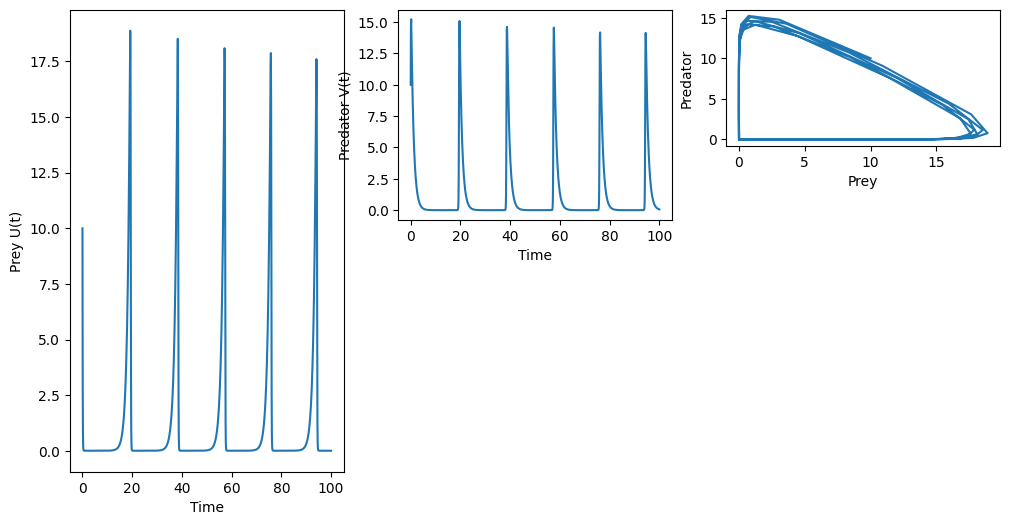

In [ ]:
def calc(initial, a, b, c, d, t, t_eval):
    def lotka_voltera(t, y):
        X, Y = y
        dX = X*a - b*X*Y
        dY = -Y*c + X*Y*d
        return[dX,dY]

    sol = solve_ivp(lotka_voltera, t_span=t, y0=initial, t_eval=t_eval)

    U = sol.y[0]
    V = sol.y[1]
    t = sol.t

    plt.figure(figsize=(12, 6))

    plt.subplot(1,3,1)
    plt.plot(t,U)
    plt.xlabel("Time")
    plt.ylabel("Prey U(t)")

    plt.subplot(2,3,2)
    plt.plot(t,V)
    plt.xlabel("Time")
    plt.ylabel("Predator V(t)")

    plt.subplot(3,3,3)
    plt.plot(U,V,label=f'a={a},b={b},c={c},d={d}')
    plt.xlabel("Prey")
    plt.ylabel("Predator")

    plt.show()

a = 1.0
b = 1.0
c = 1.0
d = 0.8
T = 100.0
t = np.array([0.0,T])
t_eval = np.linspace(0, T, 1000)

x0, y0 = 10.0, 10.0

initial = np.array([x0,y0])

sol = calc(initial, a, b, c, d, t, t_eval)

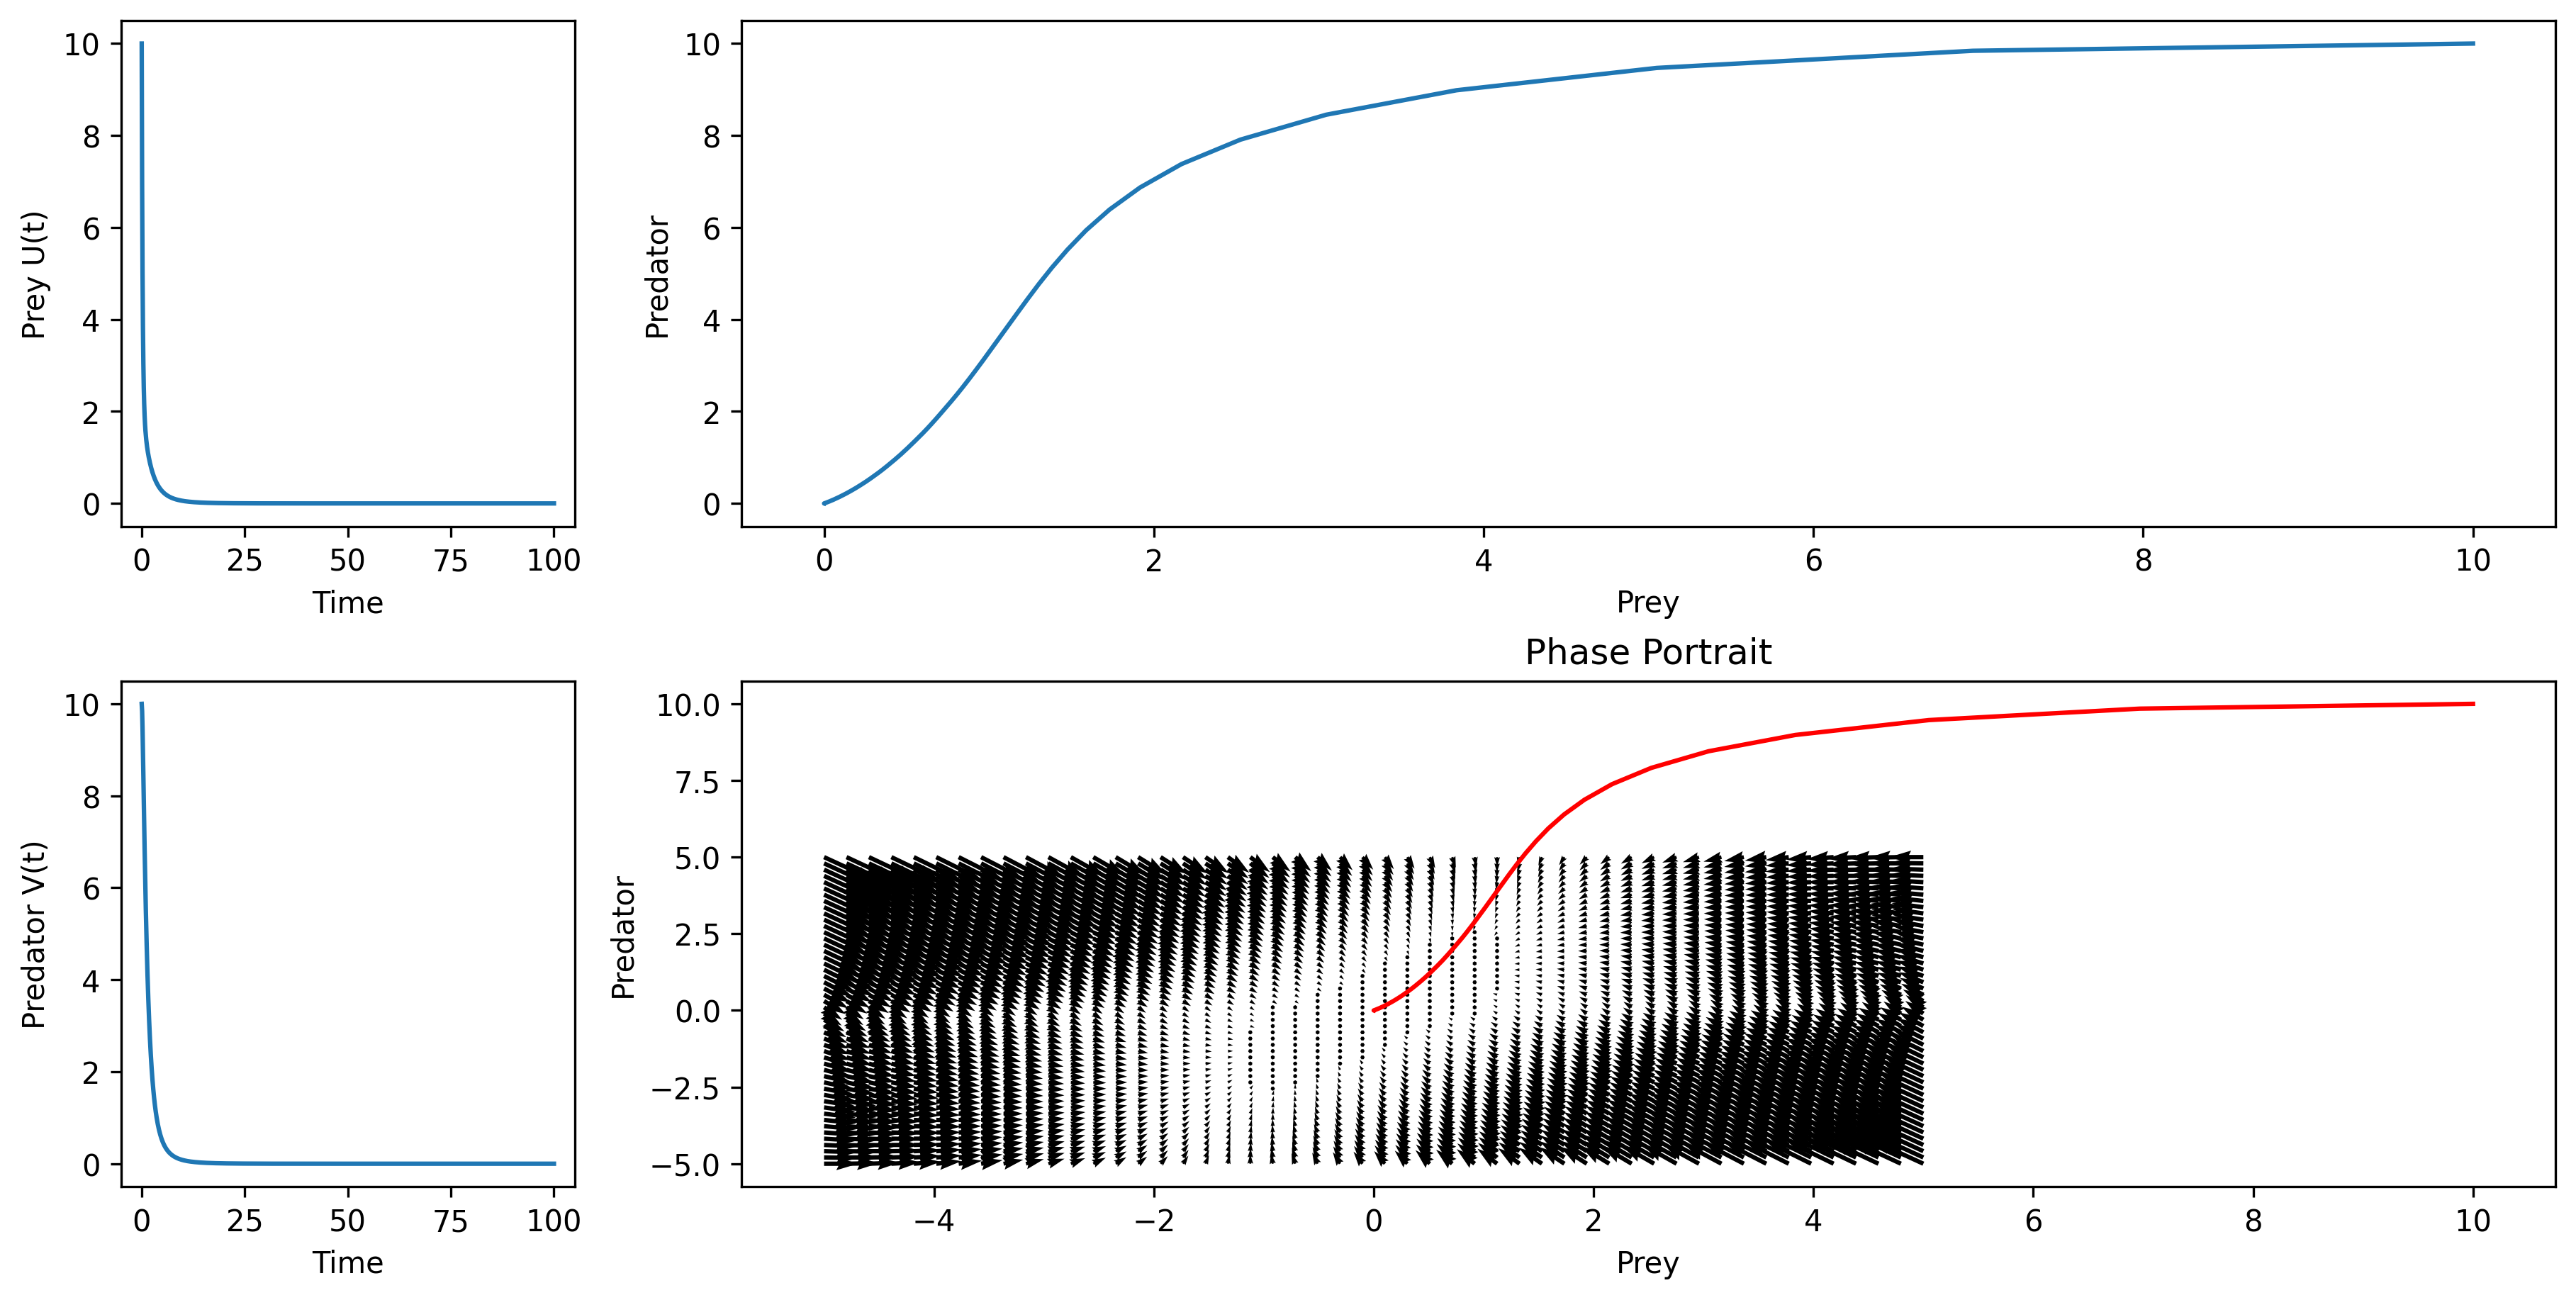

In [41]:


def calc(initial, a, b, c, d, t, t_eval):
    Z = lambda y: 1+np.sqrt(np.abs(y))
    
    def test(t, y):
        X, Y = y
        dX = -a*Z(Y)*X +b*Y
        dY = -Y + X
        return[dX,dY]

    sol = solve_ivp(test, t_span=t, y0=initial, t_eval=t_eval)

    U = sol.y[0]
    V = sol.y[1]
    t = sol.t

    fig, axes = plt.subplots(2,2,figsize=(12, 6),gridspec_kw={"width_ratios": [1,4]},constrained_layout=True, dpi = 300)

    axes[0][0].plot(t,U)
    axes[0][0].set_xlabel("Time")
    axes[0][0].set_ylabel("Prey U(t)")

    axes[1][0].plot(t,V)
    axes[1][0].set_xlabel("Time")
    axes[1][0].set_ylabel("Predator V(t)")

    axes[0][1].plot(U,V,label=f'a={a},b={b},c={c},d={d}')
    axes[0][1].set_xlabel("Prey")
    axes[0][1].set_ylabel("Predator")

    x_vals = np.linspace(-5,5,50)
    y_vals = np.linspace(-5,5,50)
    X, Y = np.meshgrid(x_vals, y_vals)

    K = -a*Z(Y)*X +b*Y
    L = -Y + X

    axes[1][1].quiver(X, Y, K, L)
    axes[1][1].plot(U,V,'r',label=f'nullclines of z(y) = 1 + y^2')
    axes[1][1].set_xlabel("Prey")
    axes[1][1].set_ylabel("Predator")
    axes[1][1].set_title("Phase Portrait")

    plt.show()

a = 1.1
b = 0.8
c = 1.0
d = 0.8
T = 100.0
t = np.array([0.0,T])
t_eval = np.linspace(0, T, 1000)

x0, y0 = 10.0, 10.0

initial = np.array([x0,y0])

sol = calc(initial, a, b, c, d, t, t_eval)

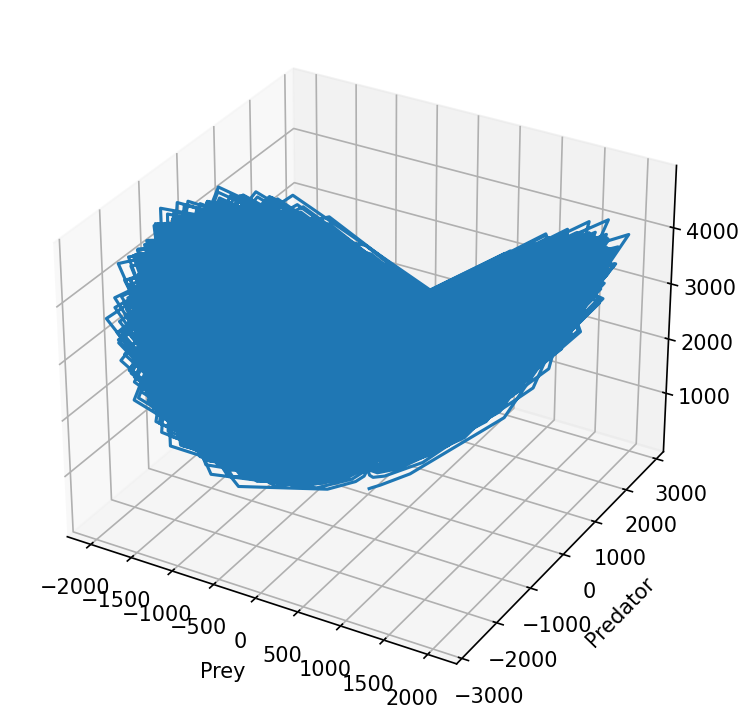

In [20]:
def calc(initial, a, b, c, d, t, t_eval):

    RO = lambda y: y
    SIGMA = lambda y: y
    BETA = lambda y: y

    def butterfly(t, y):
        X, Y, Z = y
        dX = SIGMA(a)*(Y-X)
        dY = X*(RO(b)-Z) - Y
        dZ = X*Y - BETA(c)*Z
        return np.array([dX,dY,dZ])

    sol = solve_ivp(butterfly, t_span=t, y0=initial, t_eval=t_eval)

    U = sol.y[0]
    V = sol.y[1]
    K = sol.y[2]
    t = sol.t

    fig = plt.figure(figsize=(8,6), dpi=150)
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(U,V,K)
    ax.set_xlabel("Prey")
    ax.set_ylabel("Predator")

    # Line object to update
    line, = ax.plot([], [], [], lw=1, color='blue')
    skip = 100
    x_anim = U[::skip]
    y_anim = V[::skip]
    z_anim = K[::skip]
    window = 500

    # --- Initialization function ---
    def init():
        line.set_data([], [])
        line.set_3d_properties([])
        return line,

    # --- Animation function ---
    def update(frame):
        start = max(0,frame-window)
        # Plot up to current frame
        line.set_data(x_anim[start:frame], y_anim[start:frame])
        line.set_3d_properties(z_anim[start:frame])
        return line,

    # --- Create animation ---
    anim = FuncAnimation(
        fig, update, frames=len(t_eval)-1, init_func=init, blit=True, interval=10
    )

    #anim.save("lorenz_butterfly.mp4", fps=30, dpi=200)

    plt.show()

a = 1000.0
b = 2800.0
c = 800/3
d = 0.8
T = 100.0
t = np.array([0.0,T])
t_eval = np.linspace(0, T, 100000)

x0, y0, z0 = 10.0, 10.0, 10.0

initial = np.array([x0,y0,z0])

sol = calc(initial, a, b, c, d, t, t_eval)